# Rank-weight sweep for the preferred forward search

This experiment sweeps `combined_rank` weights from 0.75 through 0.95 while
holding the current preferred search fixed: forward addition factor 0.1,
20-feature cap, separate feature sets and parameters, five members, no
ensemble holdout, three seeds, gamma scaling during search, post-search knee
selection, and final retuning.

In [1]:
import time
from pathlib import Path
import copy
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "mistic" / "svmSet.py").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

Matplotlib is building the font cache; this may take a moment.


## Fixed synthetic data and blind split

In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    class_sep=1.0,
    flip_y=0.03,
    shuffle=False,
    random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

MODEL_COUNTS = [5]
REFINEMENT_STEPS = [0, 10, 20, 50, 100]
SELECTION_STRATEGIES = ["forward_knee", "backward_knee"]
INNER_SEEDS = list(range(3))
BLIND_SET_SEED = 42
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
ENSEMBLE_VALIDATION_SIZE = 0.0
RANK_WEIGHT = 0.75
FORWARD_MAX_FEATURES = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")

Training rows: 375; fixed blind rows: 125


## Search and evaluation helpers

In [3]:
def parameter_grid():
    return [
        paramSet(model={"C": cost}, kernel={"gamma": gamma})
        for cost in C_VALUES for gamma in GAMMA_VALUES
    ]


def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def ranked_unified_features(ensemble, limit=20):
    unified_set = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([
        feature for feature in ensemble.unified_sorted_features
        if feature in unified_set
    ], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    precision = signal_count / len(features) if len(features) else 0.0
    return signal_count / len(SIGNAL_FEATURES), precision


def fit_rank_weight_ensemble(rank_weight, seed):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled,
        np.asarray(y_train),
        num_feature_medoids=20,
        ensemble_validation_size=0.0,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=5,
        validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"),
        splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True,
        separate_parameters=True,
    )
    options = dict(
        parameter_grid=parameter_grid(),
        feature_ranker=combined_rank(weight=rank_weight).compute,
        set_for_rank="sample",
        tune_models_each_step=False,
        post_find_knee=True,
    )
    ensemble.greedy_forward_selection(
        addition_factor=0.1,
        max_features=20,
        **options,
    )
    return scaler, ensemble


def result_row(ensemble, scaler, rank_weight, seed, elapsed):
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    decisions = ensemble.decision_function(X_blind_scaled)
    top20 = ranked_unified_features(ensemble, 20)
    signal_recall, signal_precision = recovery(top20)
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i)
        for i in range(ensemble.num_models)
    ])
    disagreement = np.mean([
        np.mean(member_predictions[:, i] != member_predictions[:, j])
        for i in range(ensemble.num_models)
        for j in range(i + 1, ensemble.num_models)
    ])
    selected_counts = [len(features) for features in ensemble.features]
    return {
        "seed": seed,
        "direction": "forward",
        "addition_factor": 0.1,
        "rank_weight": rank_weight,
        "num_models": ensemble.num_models,
        "mean_member_features": np.mean(selected_counts),
        "min_member_features": np.min(selected_counts),
        "max_member_features": np.max(selected_counts),
        "num_unified_features": len(ensemble.unified_features),
        "top20_signal_recall": signal_recall,
        "top20_signal_precision": signal_precision,
        "member_disagreement": disagreement,
        "search_curve_points": len(ensemble.feature_performance_),
        "elapsed_seconds": elapsed,
        **metric_row(y_blind, predictions, decisions),
    }


## Execute rank-weight sweep

In [4]:
RANK_WEIGHTS = [0.75, 0.80, 0.85, 0.90, 0.95]

rows = []
curve_rows = []
for rank_weight in RANK_WEIGHTS:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble = fit_rank_weight_ensemble(rank_weight, seed)
        elapsed = time.perf_counter() - started
        rows.append(result_row(
            ensemble, scaler, rank_weight, seed, elapsed
        ))
        for step, performance in ensemble.feature_performance_.items():
            curve_rows.append({
                "rank_weight": rank_weight,
                "seed": seed,
                "step": step,
                "num_features": performance.num_features,
                "cv_score": performance.score,
            })
        print(
            f"completed rank_weight={rank_weight}, seed={seed}; "
            f"AUC={rows[-1]['roc_auc']:.4f}; "
            f"member features={rows[-1]['mean_member_features']:.1f}; "
            f"elapsed={elapsed:.1f}s"
        )

rank_results = pd.DataFrame(rows)
rank_curves = pd.DataFrame(curve_rows)
rank_results.to_csv(
    repo_root / "validation/Synthetic100_forward_addition01_rank_weight_sweep_results.csv",
    index=False,
)
rank_curves.to_csv(
    repo_root / "validation/Synthetic100_forward_addition01_rank_weight_sweep_curves.csv",
    index=False,
)
rank_results

Number of Features: 1, Score: 0.698


Number of Features: 10, Score: 0.791


Number of Features: 19, Score: 0.786


Number of Features: 20, Score: 0.786
Number of Features: 100, Score: 0.768


completed rank_weight=0.75, seed=0; AUC=0.9591; member features=10.0; elapsed=10.8s


...

Number of Features: 10, Score: 0.738


Number of Features: 19, Score: 0.724


Number of Features: 20, Score: 0.727
Number of Features: 100, Score: 0.703


completed rank_weight=0.95, seed=2; AUC=0.9640; member features=10.0; elapsed=5.4s


,seed,direction,addition_factor,rank_weight,num_models,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,search_curve_points,elapsed_seconds,roc_auc,f1,balanced_accuracy,accuracy
0,0,forward,0.1,0.75,5,10.0,10,10,23,0.60,0.600000,0.1568,5,10.805642,0.959110,0.867257,0.879529,0.880
1,1,forward,0.1,0.75,5,20.0,20,20,39,0.65,0.650000,0.1840,5,6.091910,0.956522,0.881356,0.891822,0.888
2,2,forward,0.1,0.75,5,10.0,10,10,25,0.65,0.650000,0.1824,5,6.098005,0.962733,0.892857,0.902950,0.904
3,0,forward,0.1,0.80,5,10.0,10,10,20,0.65,0.650000,0.1376,5,8.588069,0.964027,0.857143,0.868401,0.864
4,1,forward,0.1,0.80,5,19.0,19,19,33,0.65,0.650000,0.1312,5,6.585494,0.964545,0.846154,0.863872,0.872
5,2,forward,0.1,0.80,5,10.0,10,10,20,0.70,0.700000,0.1248,5,5.552876,0.960145,0.859649,0.872283,0.872
6,0,forward,0.1,0.85,5,10.0,10,10,16,0.60,0.750000,0.0832,5,5.819394,0.971532,0.884956,0.895704,0.896
7,1,forward,0.1,0.85,5,10.0,10,10,18,0.65,0.722222,0.0928,5,5.632611,0.968685,0.867257,0.879529,0.880
8,2,forward,0.1,0.85,5,10.0,10,10,18,0.70,0.777778,0.1008,5,5.688272,0.964803,0.879310,0.890140,0.888
9,0,forward,0.1,0.90,5,10.0,10,10,16,0.60,0.750000,0.0864,5,6.644864,0.971273,0.894737,0.904633,0.904


## Aggregate comparison

In [5]:
rank_summary = rank_results.groupby("rank_weight").agg(
    mean_auc=("roc_auc", "mean"),
    sd_auc=("roc_auc", "std"),
    mean_f1=("f1", "mean"),
    mean_accuracy=("accuracy", "mean"),
    mean_balanced_accuracy=("balanced_accuracy", "mean"),
    mean_signal_recall=("top20_signal_recall", "mean"),
    mean_signal_precision=("top20_signal_precision", "mean"),
    mean_member_disagreement=("member_disagreement", "mean"),
    mean_member_features=("mean_member_features", "mean"),
    mean_unified_features=("num_unified_features", "mean"),
    mean_curve_points=("search_curve_points", "mean"),
    mean_elapsed_seconds=("elapsed_seconds", "mean"),
).reset_index()
rank_summary.round(4)

,rank_weight,mean_auc,sd_auc,mean_f1,mean_accuracy,mean_balanced_accuracy,mean_signal_recall,mean_signal_precision,mean_member_disagreement,mean_member_features,mean_unified_features,mean_curve_points,mean_elapsed_seconds
0,0.75,0.9595,0.0031,0.8805,0.8907,0.8914,0.6333,0.6333,0.1744,13.3333,29.0000,5.0,7.6652
1,0.80,0.9629,0.0024,0.8543,0.8693,0.8682,0.6667,0.6667,0.1312,13.0000,24.3333,5.0,6.9088
2,0.85,0.9683,0.0034,0.8772,0.8880,0.8885,0.6500,0.7500,0.0923,10.0000,17.3333,5.0,5.7134
3,0.90,0.9693,0.0024,0.8927,0.9013,0.9028,0.6167,0.7875,0.0816,10.0000,15.6667,5.0,7.2989
4,0.95,0.9649,0.0024,0.8895,0.8960,0.8996,0.5667,0.7577,0.0816,10.0000,15.0000,5.0,5.6004


## Paired AUC changes relative to weight 0.75

In [6]:
auc_by_seed = rank_results.pivot(
    index="seed", columns="rank_weight", values="roc_auc"
)
paired_auc_deltas = auc_by_seed.subtract(auc_by_seed[0.75], axis=0)
paired_auc_deltas.columns = [
    f"weight_{weight}_minus_0.75" for weight in paired_auc_deltas.columns
]
paired_auc_deltas.round(4)

,weight_0.75_minus_0.75,weight_0.8_minus_0.75,weight_0.85_minus_0.75,weight_0.9_minus_0.75,weight_0.95_minus_0.75
seed,,,,,
0,0.0,0.0049,0.0124,0.0122,0.0039
1,0.0,0.0080,0.0122,0.0101,0.0111
2,0.0,-0.0026,0.0021,0.0072,0.0013


## Blind performance and feature recovery

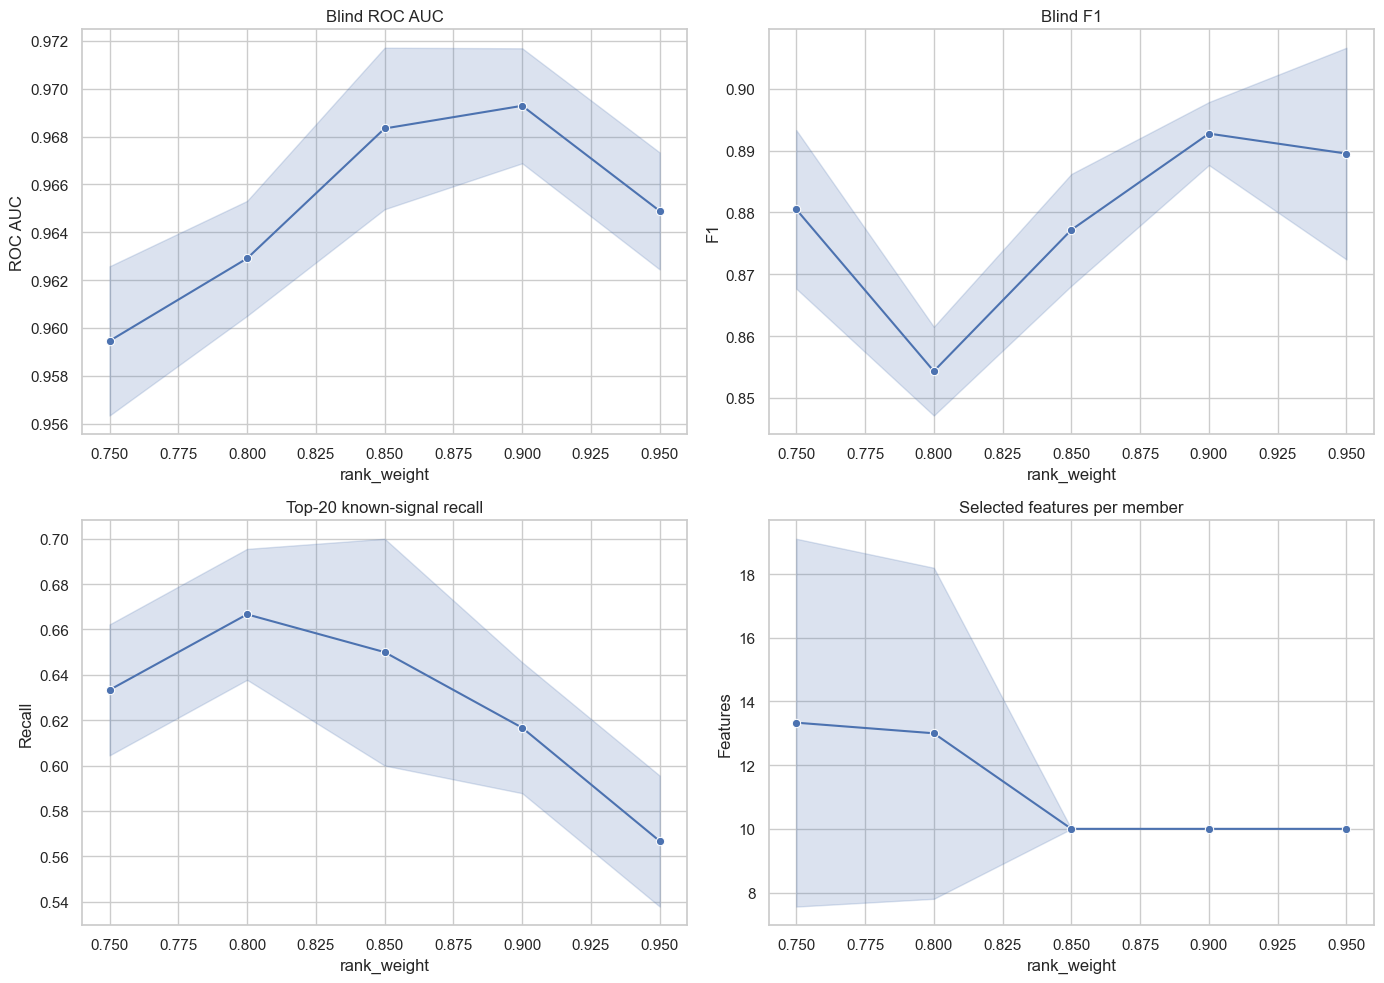

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.lineplot(data=rank_results, x="rank_weight", y="roc_auc", marker="o", errorbar="sd", ax=axes[0, 0])
axes[0, 0].set(title="Blind ROC AUC", ylabel="ROC AUC")
sns.lineplot(data=rank_results, x="rank_weight", y="f1", marker="o", errorbar="sd", ax=axes[0, 1])
axes[0, 1].set(title="Blind F1", ylabel="F1")
sns.lineplot(data=rank_results, x="rank_weight", y="top20_signal_recall", marker="o", errorbar="sd", ax=axes[1, 0])
axes[1, 0].set(title="Top-20 known-signal recall", ylabel="Recall")
sns.lineplot(data=rank_results, x="rank_weight", y="mean_member_features", marker="o", errorbar="sd", ax=axes[1, 1])
axes[1, 1].set(title="Selected features per member", ylabel="Features")
plt.tight_layout()

## Feature-performance curves

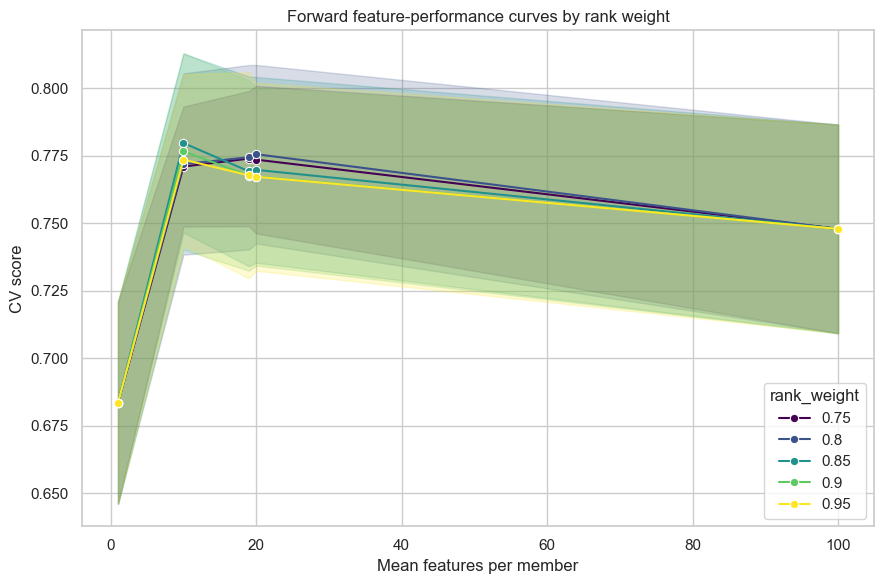

In [8]:
plt.figure(figsize=(9, 6))
sns.lineplot(
    data=rank_curves, x="num_features", y="cv_score", hue="rank_weight",
    errorbar="sd", marker="o", palette="viridis",
)
plt.title("Forward feature-performance curves by rank weight")
plt.xlabel("Mean features per member")
plt.ylabel("CV score")
plt.tight_layout()